In [1]:
import numpy as np
import sys, os
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.constants import lambda2nu, nu2lambda, c
lumapiFile = "C:\\Program Files\\Lumerical\\v221\\api\\python\\lumapi.py"

import importlib.util
import sys

spec = importlib.util.spec_from_file_location("lumapi", lumapiFile)
lumapi = importlib.util.module_from_spec(spec)
sys.modules["lumapi"] = lumapi
spec.loader.exec_module(lumapi)

import lumapi

C:\Program Files\Lumerical\v221\api\python\lumapi.py:796: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [2]:
from IPython.core.display import HTML
from IPython.display import display, Math
from IPython.core.pylabtools import figsize

HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

figsize(8, 4)

In [3]:
modeApi = lumapi.MODE(hide = False)

#units

um = 1e-6
nm = 1e-9

## Specifying the device dimensions and materials ##

In [4]:
#Materials:
material = 'Si (Silicon) - Palik'
sub_material = 'SiO2 (Glass) - Palik'

#Device dimensions:

base_width = 9 * um
rib_width_array = np.linspace(0.5,3,21)*um #W_{co}
H = 0.4 * um

#Solver and mesh dimensions:

x_span_FDE = 1.25 * base_width
y_span_FDE = 1 * um
x_span_mesh = base_width
y_span_mesh = H

#Solver and mesh parameters:

solver_mesh_cells = 100
mesh_multiplier = 4

## Building the device ##

In [5]:
modeApi.addrect()
modeApi.set('name', 'top_layer')
modeApi.set('x', 0)
modeApi.set('x span', rib_width_array[-1])
modeApi.set('y min', 0)
modeApi.set('y max', 0.5*H)
modeApi.set('material', material)

modeApi.addrect()
modeApi.set('name', 'bottom_layer')
modeApi.set('x', 0)
modeApi.set('x span', base_width)
modeApi.set('y max', 0)
modeApi.set('y min', -0.5 *H)
modeApi.set('material', material)

modeApi.addfde()
modeApi.set('x', 0)
modeApi.set('x span', x_span_FDE)
modeApi.set('y', 0)
modeApi.set('y span', y_span_FDE)
modeApi.set('x min bc', 'PML')
modeApi.set('x max bc', 'PML')
modeApi.set('y min bc', 'PML')
modeApi.set('y max bc', 'PML')
modeApi.set('define x mesh by', 'number of mesh cells')
modeApi.set('define y mesh by', 'number of mesh cells')
modeApi.set('mesh cells x', solver_mesh_cells)
modeApi.set('mesh cells y', solver_mesh_cells)
modeApi.set('background material', sub_material)

modeApi.addmesh()
modeApi.set('x', 0)
modeApi.set('x span', x_span_mesh)
modeApi.set('y', 0)
modeApi.set('y span', y_span_mesh)
modeApi.set('set mesh multiplier', 1)
modeApi.set('x mesh multiplier', mesh_multiplier)
modeApi.set('y mesh multiplier', mesh_multiplier)

modeApi.save('RIB_waveguide_FDE')

In [6]:
modeApi.findmodes()

20.0

[]

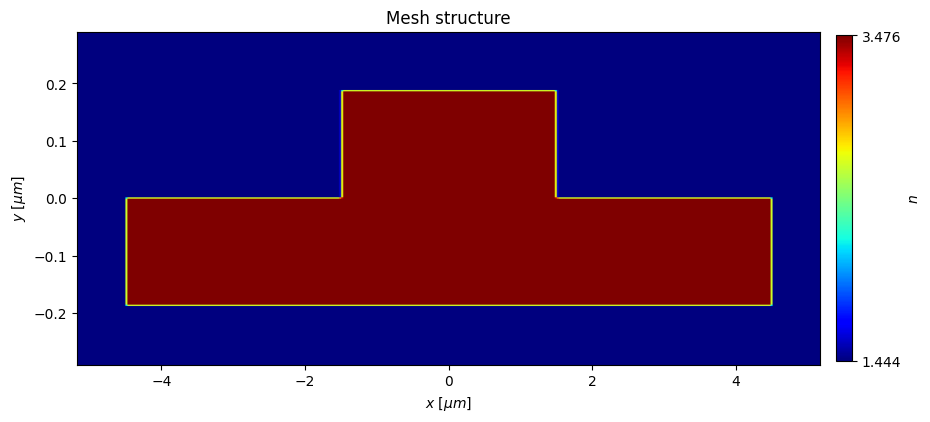

In [52]:
index_x = np.squeeze(modeApi.getdata('FDE::data::material', 'index_x'))

fig = plt.figure(figsize = (10,8))
im = plt.imshow(np.rot90(index_x), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], cmap = plt.get_cmap('jet'), aspect=8)
plt.xlabel(r'$x$ [$\mu m$]')
plt.ylabel(r'$y$ [$\mu m$]')
plt.title('Mesh structure')
colorbar =plt.colorbar(im, fraction = 0.021, pad =0.02, label = r'$n$')
colorbar.set_ticks([np.min(index_x), np.max(index_x)])
plt.plot()

In [8]:
print(np.shape(index_x))

(369, 249)


## Raising the graph $n_{eff}$ x $w_{co}$ ##

In [73]:
Nmax = int(modeApi.findmodes())

n_eff_matrix = np.zeros((len(rib_width_array),Nmax))
TE_polarization_matrix = np.zeros((len(rib_width_array),Nmax))

In [74]:
for i in range(0, len(rib_width_array), 1):
    modeApi.switchtolayout()
    modeApi.setnamed('top_layer', 'x span', rib_width_array[i])
    n = int(modeApi.findmodes())
    for j in range(0, n, 1):
        n_eff_matrix[i,j] = np.real(modeApi.getdata('mode%d' %(j+1), 'neff'))[0,0]

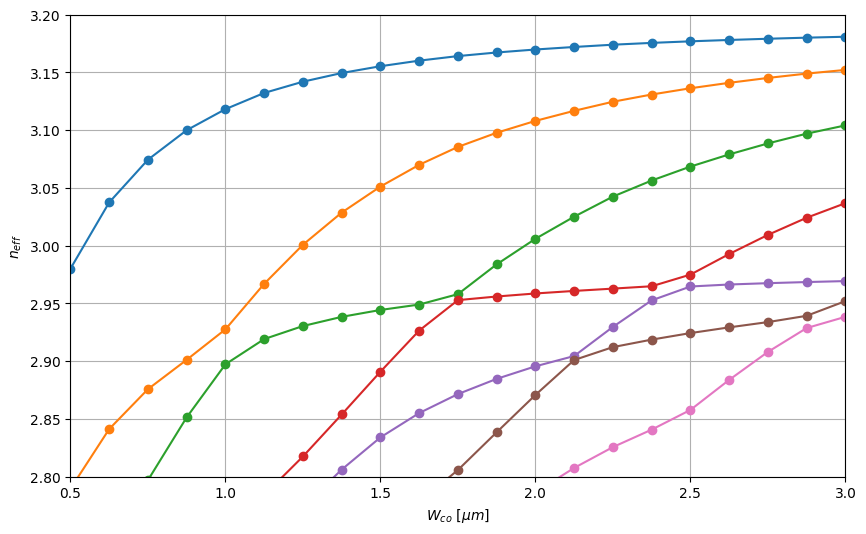

In this guide, TE modes have a steeper gradient than TM modes.


In [75]:
fig = plt.figure(figsize = (10,6))
for j in range(0, 7, 1):
    plt.plot(rib_width_array/um,n_eff_matrix[:,j], 'o-')
plt.ylim(2.8, 3.2)
plt.xlim([rib_width_array[0]/um, rib_width_array[-1]/um])
plt.grid(True)
plt.ylabel(r'$n_{eff}$')
plt.xlabel(r'$W_{co}$ [$\mu m$]')
plt.show()

print('\033[1mIn this guide, TE modes have a steeper gradient than TM modes.\033[0m')

## Visualizing the electric fiel profile ##

### When $w_{co} = 2.45\mu m$ ###

In [54]:
modeApi.switchtolayout()
modeApi.setnamed('top_layer', 'x span', 2.45*um)

n = int(modeApi.findmodes())

In [55]:
eField_4_x = np.abs(np.squeeze(modeApi.getdata('mode4', 'Ex')))
eField_5_x = np.abs(np.squeeze(modeApi.getdata('mode5', 'Ex')))
eField_4_y = np.abs(np.squeeze(modeApi.getdata('mode4', 'Ey')))
eField_5_y = np.abs(np.squeeze(modeApi.getdata('mode5', 'Ey')))

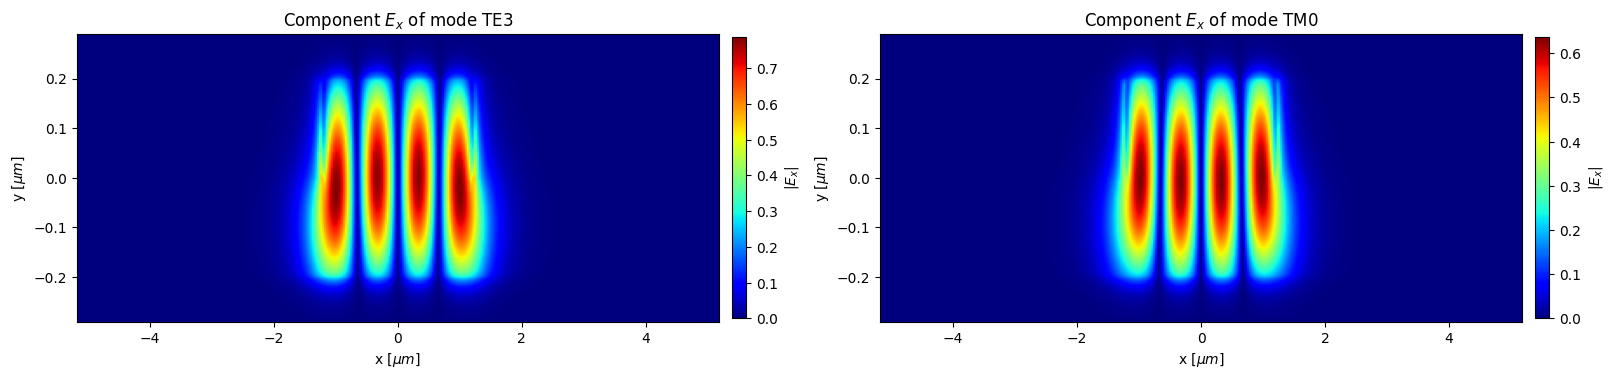

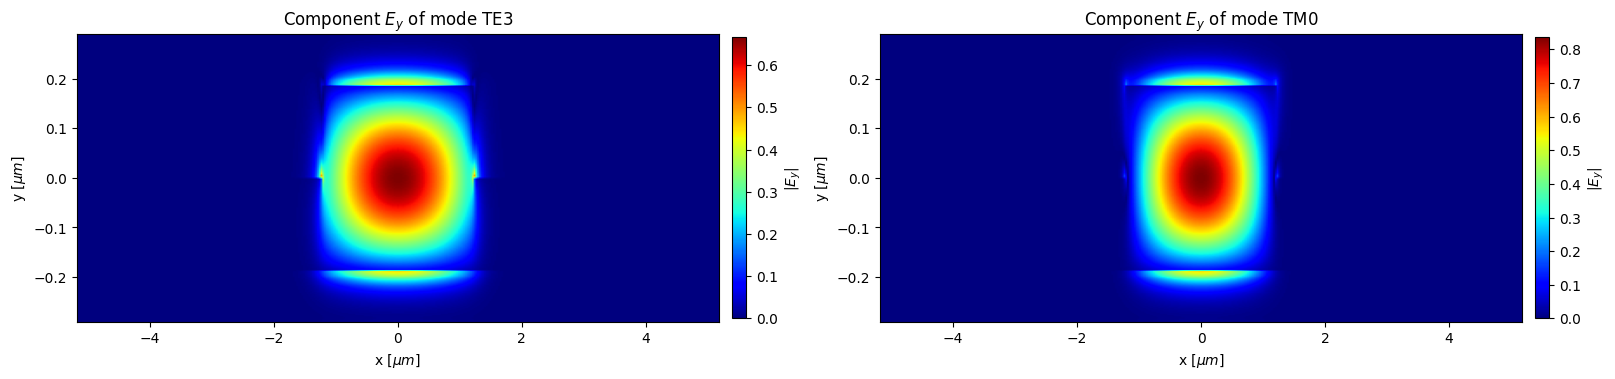

In [56]:
fig, ax = plt.subplots(1,2, figsize=(19, 8))

im1 = ax[0].imshow(np.rot90(eField_4_x),  vmin = 0, vmax = np.max(eField_4_x), cmap = plt.get_cmap('jet'), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], aspect=8)
ax[0].set_title(r'Component $E_x$ of mode TE3')
ax[0].set_xlabel(r'x [$\mu m$]')
ax[0].set_ylabel(r'y [$\mu m$]')

im2 =ax[1].imshow(np.rot90(eField_5_x),  vmin = 0, vmax = np.max(eField_5_x), cmap = plt.get_cmap('jet'), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], aspect=8)
ax[1].set_title(r'Component $E_x$ of mode TM0')
ax[1].set_xlabel(r'x [$\mu m$]')
ax[1].set_ylabel(r'y [$\mu m$]')

fig.colorbar(im1, ax=ax[0], fraction = 0.021, pad =0.02, label = r'$|E_x|$')
fig.colorbar(im2, ax=ax[1], fraction = 0.021, pad =0.02, label = r'$|E_x|$')

plt.show()

fig, ax = plt.subplots(1,2, figsize=(19, 8))

im1 = ax[0].imshow(np.rot90(eField_4_y),  vmin = 0, vmax = np.max(eField_4_y), cmap = plt.get_cmap('jet'), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], aspect=8)
ax[0].set_title(r'Component $E_y$ of mode TE3')
ax[0].set_xlabel(r'x [$\mu m$]')
ax[0].set_ylabel(r'y [$\mu m$]')

im2 =ax[1].imshow(np.rot90(eField_5_y),  vmin = 0, vmax = np.max(eField_5_y), cmap = plt.get_cmap('jet'), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], aspect=8)
ax[1].set_title(r'Component $E_y$ of mode TM0')
ax[1].set_xlabel(r'x [$\mu m$]')
ax[1].set_ylabel(r'y [$\mu m$]')

fig.colorbar(im1, ax=ax[0], fraction = 0.021, pad =0.02, label = r'$|E_y|$')
fig.colorbar(im2, ax=ax[1], fraction = 0.021, pad =0.02, label = r'$|E_y|$')

plt.show()

### When $w_{co} = 1\mu m$ ###

In [57]:
modeApi.switchtolayout()
modeApi.setnamed('top_layer', 'x span', 1*um)

n = int(modeApi.findmodes())

In [59]:
eField_2_x = np.abs(np.squeeze(modeApi.getdata('mode2', 'Ex')))
eField_3_x = np.abs(np.squeeze(modeApi.getdata('mode3', 'Ex')))
eField_2_y = np.abs(np.squeeze(modeApi.getdata('mode2', 'Ey')))
eField_3_y = np.abs(np.squeeze(modeApi.getdata('mode3', 'Ey')))

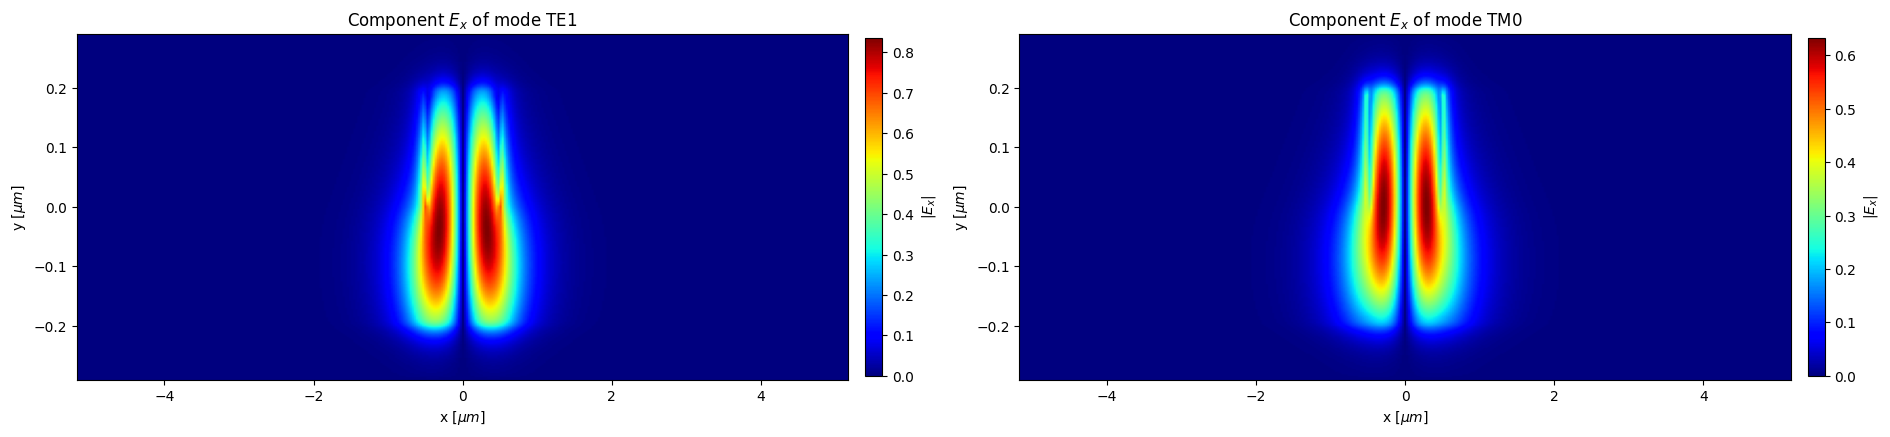

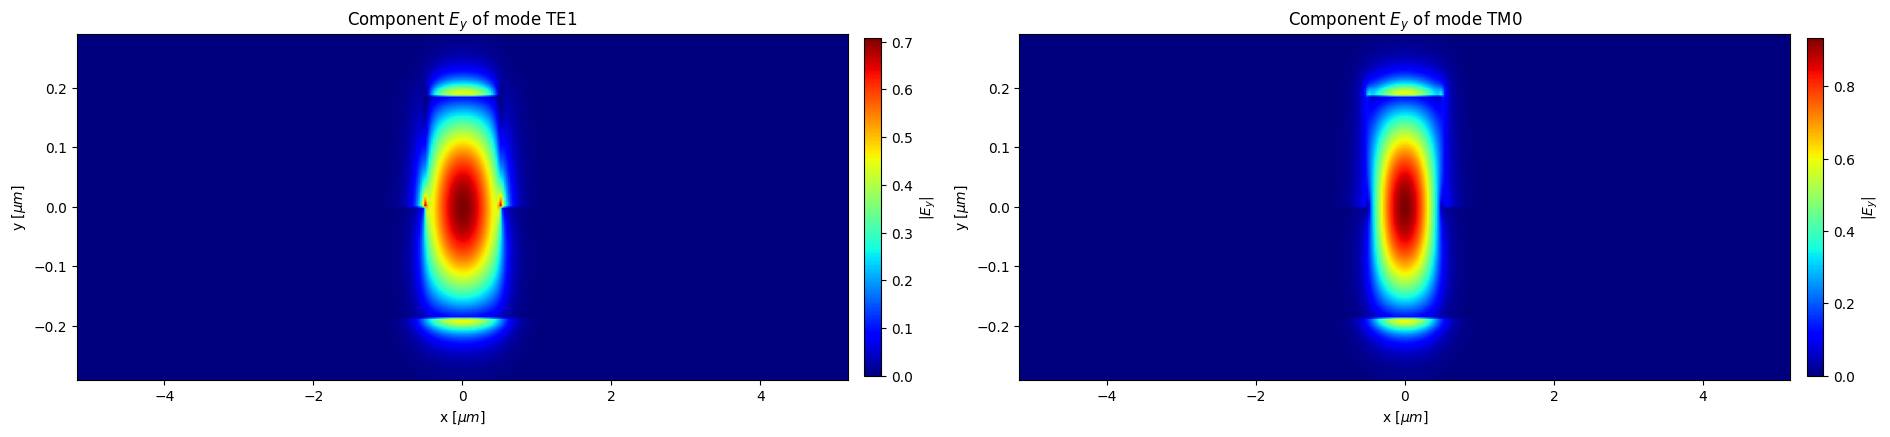

In [62]:
fig, ax = plt.subplots(1,2, figsize=(19, 8))

im1 = ax[0].imshow(np.rot90(eField_2_x),  vmin = 0, vmax = np.max(eField_2_x), cmap = plt.get_cmap('jet'), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], aspect=8)
ax[0].set_title(r'Component $E_x$ of mode TE1')
ax[0].set_xlabel(r'x [$\mu m$]')
ax[0].set_ylabel(r'y [$\mu m$]')

im2 =ax[1].imshow(np.rot90(eField_3_x),  vmin = 0, vmax = np.max(eField_3_x), cmap = plt.get_cmap('jet'), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], aspect=8)
ax[1].set_title(r'Component $E_x$ of mode TM0')
ax[1].set_xlabel(r'x [$\mu m$]')
ax[1].set_ylabel(r'y [$\mu m$]')

fig.colorbar(im1, ax=ax[0], fraction = 0.021, pad =0.021, label = r'$|E_x|$')
fig.colorbar(im2, ax=ax[1], fraction = 0.021, pad =0.021, label = r'$|E_x|$')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1,2, figsize=(19, 8))

im1 = ax[0].imshow(np.rot90(eField_2_y),  vmin = 0, vmax = np.max(eField_2_y), cmap = plt.get_cmap('jet'), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], aspect=8)
ax[0].set_title(r'Component $E_y$ of mode TE1')
ax[0].set_xlabel(r'x [$\mu m$]')
ax[0].set_ylabel(r'y [$\mu m$]')

im2 =ax[1].imshow(np.rot90(eField_3_y),  vmin = 0, vmax = np.max(eField_3_y), cmap = plt.get_cmap('jet'), extent=[-1.15*base_width/(2*um), 1.15*base_width/(2*um), -1.45*H/(2*um), 1.45*H/(2*um)], aspect=8)
ax[1].set_title(r'Component $E_y$ of mode TM0')
ax[1].set_xlabel(r'x [$\mu m$]')
ax[1].set_ylabel(r'y [$\mu m$]')

fig.colorbar(im1, ax=ax[0], fraction = 0.021, pad =0.02, label = r'$|E_y|$')
fig.colorbar(im2, ax=ax[1], fraction = 0.021, pad =0.02, label = r'$|E_y|$')

plt.tight_layout()
plt.show()

In [61]:
modeApi.close()